# Setup

In [1]:
import pandas as pd
import numpy as np
import torch
from torch_geometric.data import HeteroData
from sklearn.preprocessing import LabelEncoder, StandardScaler
import networkx as nx
import matplotlib.pyplot as plt


c:\Users\User\.conda\envs\signal_processing\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==========================================
# 1. LOAD AND TEMPORAL SPLIT
# ==========================================
print("Loading SAML-D dataset...")
df = pd.read_csv('SAML-D.csv', low_memory=False)

# Create a single timestamp and sort chronologically
df['Timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df = df.sort_values('Timestamp').reset_index(drop=True)

# Define windows based on your dataset range (Oct 2022 - Aug 2023)
start_date = df['Timestamp'].min()
profile_end = pd.Timestamp('2023-03-01')    # 2022-10-07 to 2023-02-28
train_end = pd.Timestamp('2023-08-01')      #  2023-03-01 to 2023-07-31
test_end = pd.Timestamp('2023-08-24')         # 2023-08-01 to 2023-08-23

print(f"Profile Window: {start_date.date()} to {profile_end.date()}")
print(f"Training Window: {profile_end.date()} to {train_end.date()}")
print(f"Testing Window: {train_end.date()} to {test_end.date()}")

# Split dataframes
hist_df = df[df['Timestamp'] < profile_end].copy()
train_df = df[(df['Timestamp'] >= profile_end) & (df['Timestamp'] < train_end)].copy()
test_df = df[(df['Timestamp'] >= train_end) & (df['Timestamp'] < test_end)].copy()

# ==========================================
print("\n")
print('Profile min/max timestamps:')
print(hist_df['Timestamp'].min(), hist_df['Timestamp'].max())
print('Train min/max timestamps:')
print(train_df['Timestamp'].min(), train_df['Timestamp'].max())
print('Test min/max timestamps:')
print(test_df['Timestamp'].min(), test_df['Timestamp'].max())

Loading SAML-D dataset...
Profile Window: 2022-10-07 to 2023-03-01
Training Window: 2023-03-01 to 2023-08-01
Testing Window: 2023-08-01 to 2023-08-24


Profile min/max timestamps:
2022-10-07 10:35:19 2023-02-28 23:59:59
Train min/max timestamps:
2023-03-01 00:00:17 2023-07-31 23:59:59
Test min/max timestamps:
2023-08-01 00:00:01 2023-08-23 10:57:12


In [3]:
df.head()

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type,Timestamp
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits,2022-10-07 10:35:19
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out,2022-10-07 10:35:20
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out,2022-10-07 10:35:20
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In,2022-10-07 10:35:21
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits,2022-10-07 10:35:21


In [4]:
df.shape, pd.concat([df['Sender_account'], df['Receiver_account']]).nunique()

((9504852, 13), 855460)

In [5]:
train_df.shape, pd.concat([train_df['Sender_account'], train_df['Receiver_account']]).nunique()

((4528528, 13), 610973)

In [6]:
test_df.shape, pd.concat([test_df['Sender_account'], test_df['Receiver_account']]).nunique()

((656582, 13), 258616)

In [3]:
df['Timestamp'].min(), df['Timestamp'].max()

(Timestamp('2022-10-07 10:35:19'), Timestamp('2023-08-23 10:57:12'))

In [4]:
# shapes of the splits
print(f"Profile set shape: {hist_df.shape}")
print(f"Training set shape: {train_df.shape}")
print(f"Testing set shape: {test_df.shape}")

Profile set shape: (4319742, 13)
Training set shape: (4528528, 13)
Testing set shape: (656582, 13)


In [139]:
print(f"Laundering Rate in Profile set: {hist_df['Is_laundering'].mean():.4%}")
print(f"Laundering Rate in Train set: {train_df['Is_laundering'].mean():.4%}")
print(f"Laundering Rate in Test set: {test_df['Is_laundering'].mean():.4%}")

Laundering Rate in Profile set: 0.0991%
Laundering Rate in Train set: 0.1052%
Laundering Rate in Test set: 0.1264%


## Analysis of Transaction Data for Feature Engineering

In [26]:
df['Amount'].min(), df['Amount'].max()

(np.float64(3.73), np.float64(12618498.4))

In [34]:
df['Payment_type'].value_counts(normalize=True)

Payment_type
Credit card        0.211777
Debit card         0.211692
Cheque             0.211620
ACH                0.211345
Cross-border       0.098258
Cash Withdrawal    0.031613
Cash Deposit       0.023694
Name: proportion, dtype: float64

# Costumer profiling features

In [5]:
# 1. SETUP PARAMETERS
HIGH_RISK_COUNTRIES = ['Mexico', 'Turkey', 'Morocco', 'UAE']
CASH_TYPES = ['Cash Deposit', 'Cash Withdrawal']
THRESHOLD_MIN = 9000
THRESHOLD_MAX = 10000

# Boundary for snapshot
snapshot_date = pd.Timestamp('2023-03-01')

# List of unique customers needing features (Train + Test nodes)
all_unique_customers = pd.concat([
    train_df['Sender_account'], train_df['Receiver_account'], 
    test_df['Sender_account'], test_df['Receiver_account']
]).unique()

In [6]:
all_unique_customers.shape

(646548,)

In [7]:
# 2. PRE-PROCESS HISTORY FOR SPEED
# Create flags for high-risk behaviors to make grouping faster
hist_df['is_high_risk'] = hist_df['Receiver_bank_location'].isin(HIGH_RISK_COUNTRIES).astype(int)
hist_df['is_cash'] = hist_df['Payment_type'].isin(CASH_TYPES).astype(int)
hist_df['is_cross_border'] = (hist_df['Sender_bank_location'] != hist_df['Receiver_bank_location']).astype(int)
hist_df['is_structuring'] = ((hist_df['Amount'] >= THRESHOLD_MIN) & (hist_df['Amount'] < THRESHOLD_MAX)).astype(int)

In [8]:
# 3. CORE FEATURE CALCULATION FUNCTION
def get_window_features(window_df, window_suffix):
    print(f"Processing window: {window_suffix}...")
    
    # --- SENDING BEHAVIOR ---
    sent_stats = window_df.groupby('Sender_account').agg(
        Total_Sent=('Amount', 'sum'),
        Count_Sent=('Amount', 'count'),
        Max_Sent=('Amount', 'max'),
        Min_Sent=('Amount', 'min'),
        Volatility_Sent=('Amount', 'std'),
        High_Risk_Count=('is_high_risk', 'sum'),
        Cash_Vol_Sent=('Amount', lambda x: x[window_df.loc[x.index, 'is_cash'] == 1].sum()),
        Cross_Border_Count_Sent=('is_cross_border', 'sum'),
        Structuring_Count_Sent=('is_structuring', 'sum'),
        Unique_Recipients=('Receiver_account', 'nunique')
    )
    sent_stats['Avg_Sent'] = sent_stats['Total_Sent'] / sent_stats['Count_Sent']

    # --- RECEIVING BEHAVIOR ---
    rec_stats = window_df.groupby('Receiver_account').agg(
        Total_Received=('Amount', 'sum'),
        Count_Received=('Amount', 'count'),
        Max_Received=('Amount', 'max'),
        Min_Received=('Amount', 'min'),
        Volatility_Received=('Amount', 'std'),
        Cash_Vol_Rec=('Amount', lambda x: x[window_df.loc[x.index, 'is_cash'] == 1].sum()),
        Cross_Border_Count_Rec=('is_cross_border', 'sum'),
        Structuring_Count_Rec=('is_structuring', 'sum'),
        Unique_Senders=('Sender_account', 'nunique')
    )
    rec_stats['Avg_Received'] = rec_stats['Total_Received'] / rec_stats['Count_Received']


    # Merge Sent and Received
    merged = pd.merge(sent_stats, rec_stats, left_index=True, right_index=True, how='outer').fillna(0)

    # in-out rations
    merged['Sent_Received_Ratio'] = merged['Total_Sent'] / (merged['Total_Received'] + 1e-9)

    
    # Calculate Ratios
    merged['Cash_Volume'] = merged['Cash_Vol_Sent'] + merged['Cash_Vol_Rec']
    merged['Cash_Ratio'] = merged['Cash_Volume'] / (merged['Total_Sent'] + merged['Total_Received'] + 1e-9)
    
    # Add Suffix to all columns except index
    merged.columns = [f"{col}_{window_suffix}" for col in merged.columns]
    return merged

# 4. CALCULATE ACROSS WINDOWS
# Window definitions
win_1d = hist_df[hist_df['Timestamp'] >= (snapshot_date - pd.DateOffset(days=1))]
win_7d = hist_df[hist_df['Timestamp'] >= (snapshot_date - pd.DateOffset(days=7))]
win_1m = hist_df[hist_df['Timestamp'] >= (snapshot_date - pd.DateOffset(months=1))]
win_3m = hist_df[hist_df['Timestamp'] >= (snapshot_date - pd.DateOffset(months=3))]
win_full = hist_df # The 5-month history

print("1 day window timestamp range:", win_1d['Timestamp'].min(), "to", win_1d['Timestamp'].max())
print("7 day window timestamp range:", win_7d['Timestamp'].min(), "to", win_7d['Timestamp'].max())
print("1 month window timestamp range:", win_1m['Timestamp'].min(), "to", win_1m['Timestamp'].max())
print("3 month window timestamp range:", win_3m['Timestamp'].min(), "to", win_3m['Timestamp'].max())
print("Full window timestamp range:", win_full['Timestamp'].min(), "to", win_full['Timestamp'].max())

feat_1d = get_window_features(win_1d, '1D')
feat_7d = get_window_features(win_7d, '7D')
feat_1m = get_window_features(win_1m, '1M')
feat_3m = get_window_features(win_3m, '3M')
feat_full = get_window_features(win_full, 'Full')

# 5. CONSOLIDATE AND HANDLE COLD START
print("Consolidating features and handling cold start...")
fc_matrix = pd.DataFrame(index=all_unique_customers)
fc_matrix = fc_matrix.join([feat_1d, feat_7d, feat_1m, feat_3m, feat_full], how='left').fillna(0)

1 day window timestamp range: 2023-02-28 00:00:02 to 2023-02-28 23:59:59
7 day window timestamp range: 2023-02-22 00:00:00 to 2023-02-28 23:59:59
1 month window timestamp range: 2023-02-01 00:00:05 to 2023-02-28 23:59:59
3 month window timestamp range: 2022-12-01 00:00:11 to 2023-02-28 23:59:59
Full window timestamp range: 2022-10-07 10:35:19 to 2023-02-28 23:59:59
Processing window: 1D...
Processing window: 7D...
Processing window: 1M...
Processing window: 3M...
Processing window: Full...
Consolidating features and handling cold start...


In [10]:
def get_temporal_latency_features(df, all_accounts):
    print("Calculating Advanced Latency Variations...")
    
    # 1. Create the timeline with necessary columns for typology checks
    out_events = df[['Sender_account', 'Timestamp', 'Sender_bank_location', 'Receiver_bank_location']].copy()
    out_events.columns = ['acc', 'ts', 'loc_src', 'loc_dst']
    out_events['dir'] = 'OUT'
    # Flag cross-border OUT
    out_events['is_cb_out'] = (out_events['loc_src'] != out_events['loc_dst']).astype(int)

    in_events = df[['Receiver_account', 'Timestamp', 'Payment_type', 'Sender_bank_location', 'Receiver_bank_location']].copy()
    in_events.columns = ['acc', 'ts', 'ptype', 'loc_src', 'loc_dst']
    in_events['dir'] = 'IN'
    # Flag specific IN types
    in_events['is_cash_in'] = (in_events['ptype'] == 'Cash Deposit').astype(int)
    in_events['is_layer_in'] = in_events['ptype'].isin(['Cross-border', 'ACH']).astype(int)

    # Combine and sort
    timeline = pd.concat([out_events, in_events]).sort_values(['acc', 'ts']).reset_index(drop=True)

    # 2. Shift to compare current action with previous action
    timeline['prev_acc'] = timeline['acc'].shift(1)
    timeline['prev_dir'] = timeline['dir'].shift(1)
    timeline['prev_ts']  = timeline['ts'].shift(1)
    timeline['prev_is_cash'] = timeline['is_cash_in'].shift(1)
    timeline['prev_is_layer'] = timeline['is_layer_in'].shift(1)

    # 3. Apply Typology Conditions
    # Condition: Same account AND current is OUT AND previous was IN
    base_mask = (timeline['acc'] == timeline['prev_acc']) & \
                (timeline['dir'] == 'OUT') & \
                (timeline['prev_dir'] == 'IN')
    
    # Variation 1 Mask: Cash In -> Any Out
    cash_send_mask = base_mask & (timeline['prev_is_cash'] == 1)
    
    # Variation 2 Mask: (Cross-border/ACH) In -> Cross-border Out
    layer_speed_mask = base_mask & (timeline['prev_is_layer'] == 1) & (timeline['is_cb_out'] == 1)

    # 4. Calculate Deltas
    timeline['delta_hrs'] = (timeline['ts'] - timeline['prev_ts']).dt.total_seconds() / 3600.0

    # 5. Aggregation
    temp_feats = pd.DataFrame(index=all_accounts)
    
    # Avg_Time_Cash_To_Send
    temp_feats['Avg_Time_Cash_To_Send'] = timeline[cash_send_mask].groupby('acc')['delta_hrs'].mean()
    
    # Avg_Time_Wire_To_Wire (Layering Speed)
    temp_feats['Avg_Time_Wire_To_Wire'] = timeline[layer_speed_mask].groupby('acc')['delta_hrs'].mean()
    
    # Rapid Movement Count (< 1 hour for any In->Out)
    temp_feats['Rapid_Movement_Count'] = timeline[base_mask & (timeline['delta_hrs'] < 1.0)].groupby('acc').size()

    # 6. Final Clean up
    # Use 9999 to represent "No such pattern found" (low risk)
    return temp_feats.fillna({'Avg_Time_Cash_To_Send': 9999, 'Avg_Time_Wire_To_Wire': 9999, 'Rapid_Movement_Count': 0})

In [11]:
# Calculate the new Temporal Latency features
feat_latency = get_temporal_latency_features(hist_df, all_unique_customers)

Calculating Advanced Latency Variations...


In [12]:
# Join them together
fc_matrix = fc_matrix.join(feat_latency, how='left')

In [13]:
fc_matrix.head()

,Total_Sent_1D,Count_Sent_1D,Max_Sent_1D,Min_Sent_1D,Volatility_Sent_1D,High_Risk_Count_1D,Cash_Vol_Sent_1D,Cross_Border_Count_Sent_1D,Structuring_Count_Sent_1D,Unique_Recipients_1D,...,Cross_Border_Count_Rec_Full,Structuring_Count_Rec_Full,Unique_Senders_Full,Avg_Received_Full,Sent_Received_Ratio_Full,Cash_Volume_Full,Cash_Ratio_Full,Avg_Time_Cash_To_Send,Avg_Time_Wire_To_Wire,Rapid_Movement_Count
9927770053,651.36,1.0,651.36,651.36,0.000000,0.0,0.00,0.0,0.0,1.0,...,0.0,0.0,3.0,4980.104375,1.353610e+01,23333.89,0.020146,56.457284,9999.0,0.0
3323321274,0.00,0.0,0.00,0.00,0.000000,0.0,0.00,0.0,0.0,0.0,...,0.0,0.0,6.0,3693.046522,1.633212e+01,45969.65,0.031225,27.448088,9999.0,2.0
3575195401,0.00,0.0,0.00,0.00,0.000000,0.0,0.00,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000e+00,0.00,0.000000,9999.000000,9999.0,0.0
8369158708,32385.67,3.0,29032.44,109.29,15871.470047,0.0,109.29,0.0,0.0,3.0,...,0.0,0.0,0.0,0.000000,1.125408e+15,4767.27,0.004236,9999.000000,9999.0,0.0
3026980368,296.04,1.0,296.04,296.04,0.000000,0.0,0.00,0.0,0.0,1.0,...,5.0,2.0,19.0,9507.245300,1.149890e+00,0.00,0.000000,9999.000000,9999.0,3.0


In [15]:
# 6. NORMALIZATION (Z-SCORE)
print("Applying StandardScaler...")
scaler = StandardScaler()
fc_matrix_scaled = pd.DataFrame(
    scaler.fit_transform(fc_matrix), 
    index=fc_matrix.index, 
    columns=fc_matrix.columns
)

print(f"Final Customer Feature Matrix Shape: {fc_matrix_scaled.shape}")
# Ready to be converted to torch.tensor for LaundroGraph!

Applying StandardScaler...
Final Customer Feature Matrix Shape: (646548, 123)


# TRANSACTION FEATURE ENGINEERING

In [16]:
def get_transaction_features(df_subset):
    print("Generating transaction features...")
    
    # 1. Numerical Features
    # Log transform amount (Source [2] mentions amount properties)
    amount_log = np.log1p(df_subset['Amount'].values).reshape(-1, 1)
    
    # 2. Time Features (CYCLICAL ENCODING)
    # Extract integer hour (0-23)
    hours = df_subset['Timestamp'].dt.hour
    
    # Apply Sine/Cosine transformation
    # We use 24.0 to ensure the cycle closes perfectly
    hour_sin = np.sin(2 * np.pi * hours / 24.0).values.reshape(-1, 1)
    hour_cos = np.cos(2 * np.pi * hours / 24.0).values.reshape(-1, 1)
    
    # 3. Binary Flags (Interaction Logic)
    is_cross_border = (df_subset['Sender_bank_location'] != df_subset['Receiver_bank_location']).astype(int).values.reshape(-1, 1)
    is_curr_mismatch = (df_subset['Payment_currency'] != df_subset['Received_currency']).astype(int).values.reshape(-1, 1)
    
    # Return DataFrame with the new cyclical columns
    return pd.DataFrame({
        'Amount_Log': amount_log.flatten(),
        'Hour_Sin': hour_sin.flatten(),
        'Hour_Cos': hour_cos.flatten(),
        'DayOfWeek': df_subset['Timestamp'].dt.dayofweek, # Keep separate or OHE later
        'Is_Cross_Border': is_cross_border.flatten(),
        'Is_Curr_Mismatch': is_curr_mismatch.flatten()
    }, index=df_subset.index)

In [17]:
# 3. One-Hot Encoding (Must fit on ALL data to align columns)
# Concatenate Train and Test to ensure we capture all categories
combined_tx = pd.concat([train_df, test_df])

# Create the dummy variables
# We encode: Payment_type, Sender_Location, Receiver_Location
categorical_cols = ['Payment_type', 'Sender_bank_location', 'Receiver_bank_location']
dummies = pd.get_dummies(combined_tx[categorical_cols], dummy_na=False, dtype=int)

In [18]:
# 4. Assemble the Final Matrices
# We need to split them back up because they go into different graphs (Train vs Test)

# Base numerical features
ft_num_train = get_transaction_features(train_df)
ft_num_test = get_transaction_features(test_df)

Generating transaction features...
Generating transaction features...


In [19]:
# Join with OHE dummies (aligning by index)
ft_train = ft_num_train.join(dummies.loc[train_df.index])
ft_test = ft_num_test.join(dummies.loc[test_df.index])

In [27]:
ft_num_train.head()

,Amount_Log,Hour_Sin,Hour_Cos,DayOfWeek,Is_Cross_Border,Is_Curr_Mismatch
4319742,7.801890,0.0,1.0,2,0,0
4319743,4.256888,0.0,1.0,2,0,0
4319744,8.925385,0.0,1.0,2,0,0
4319745,9.636839,0.0,1.0,2,0,0
4319746,5.409903,0.0,1.0,2,0,0


In [20]:
# 5. Final Scaling (Optional but recommended for Neural Networks)
# Scale the non-binary columns (Hour, DayOfWeek)
scaler_tx = StandardScaler()
cols_to_scale = ['Amount_Log', 'DayOfWeek']

ft_train[cols_to_scale] = scaler_tx.fit_transform(ft_train[cols_to_scale])
# Transform test using train statistics to prevent sleakage
ft_test[cols_to_scale] = scaler_tx.transform(ft_test[cols_to_scale])

print(f"Transaction Features (ft) Shape: {ft_train.shape}")

Transaction Features (ft) Shape: (4528528, 49)


# GRAPH CONSTRUCTION (HeteroData)

In [22]:
ft_train.head()

,Amount_Log,Hour_Sin,Hour_Cos,DayOfWeek,Is_Cross_Border,Is_Curr_Mismatch,Payment_type_ACH,Payment_type_Cash Deposit,Payment_type_Cash Withdrawal,Payment_type_Cheque,...,Receiver_bank_location_Morocco,Receiver_bank_location_Netherlands,Receiver_bank_location_Nigeria,Receiver_bank_location_Pakistan,Receiver_bank_location_Spain,Receiver_bank_location_Switzerland,Receiver_bank_location_Turkey,Receiver_bank_location_UAE,Receiver_bank_location_UK,Receiver_bank_location_USA
4319742,-0.391857,0.0,1.0,-0.491923,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4319743,-2.919549,0.0,1.0,-0.491923,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
4319744,0.409228,0.0,1.0,-0.491923,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4319745,0.916516,0.0,1.0,-0.491923,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4319746,-2.097415,0.0,1.0,-0.491923,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [23]:
fc_matrix_scaled.head()

,Total_Sent_1D,Count_Sent_1D,Max_Sent_1D,Min_Sent_1D,Volatility_Sent_1D,High_Risk_Count_1D,Cash_Vol_Sent_1D,Cross_Border_Count_Sent_1D,Structuring_Count_Sent_1D,Unique_Recipients_1D,...,Cross_Border_Count_Rec_Full,Structuring_Count_Rec_Full,Unique_Senders_Full,Avg_Received_Full,Sent_Received_Ratio_Full,Cash_Volume_Full,Cash_Ratio_Full,Avg_Time_Cash_To_Send,Avg_Time_Wire_To_Wire,Rapid_Movement_Count
9927770053,0.023283,0.694328,0.110390,0.173467,-0.019752,-0.007853,-0.034192,-0.011393,-0.009878,4.137305,...,-0.075542,-0.103465,1.325980,-0.048319,-0.041340,6.404878,-0.187097,-6.678254,0.082059,-0.048319
3323321274,-0.020859,-0.027462,-0.042587,-0.040541,-0.019752,-0.007853,-0.034192,-0.011393,-0.009878,-0.114335,...,-0.075542,-0.103465,3.083406,-0.079921,-0.041340,12.821776,-0.142457,-6.698177,0.082059,2.807045
3575195401,-0.020859,-0.027462,-0.042587,-0.040541,-0.019752,-0.007853,-0.034192,-0.011393,-0.009878,-0.114335,...,-0.075542,-0.103465,-0.431447,-0.170598,-0.041340,-0.209929,-0.268265,0.150097,0.082059,-0.048319
8369158708,2.173883,2.137908,6.775921,-0.004633,8.708502,-0.007853,0.966764,-0.011393,-0.009878,12.640586,...,-0.075542,-0.103465,-0.431447,-0.170598,23.619237,1.141521,-0.251198,0.150097,0.082059,-0.048319
3026980368,-0.000797,0.694328,0.026940,0.056725,-0.019752,-0.007853,-0.034192,-0.011393,-0.009878,4.137305,...,0.865237,1.048081,10.698921,0.062838,-0.041340,-0.209929,-0.268265,0.150097,0.082059,4.234727


In [24]:
# 1. GLOBAL ID MAPPING
# We need a dictionary that maps the String Account ID -> Integer Index (0 to N)
# This index corresponds to the row number in 'fc_matrix_scaled'
customer_to_idx = {cust_id: i for i, cust_id in enumerate(fc_matrix_scaled.index)}

print(f"Total Unique Customers (Nodes): {len(customer_to_idx)}")

Total Unique Customers (Nodes): 646548


In [ ]:
ft_train = pd.read_csv('ft_train.csv', index_col=0)
ft_test = pd.read_csv('ft_test.csv', index_col=0)
fc_matrix_scaled = pd.read_csv('fc_matrix_scaled.csv', index_col=0)
train_df = pd.read_csv('train_df.csv', index_col=0)
test_df = pd.read_csv('test_df.csv', index_col=0)

import pickle
with open('customer_to_idx.pkl', 'rb') as f:
    customer_to_idx = pickle.load(f)

In [66]:
test_df['Is_laundering'].value_counts()

Is_laundering
0    655752
1       830
Name: count, dtype: int64

In [ ]:
def build_global_laundrograph(train_df, test_df, ft_train, ft_test, fc_profiles):
    """
    Builds ONE global graph containing all train and test nodes/edges.
    """
    print("Building Global LaundroGraph...")
    
    # 1. Merge DataFrames to get Global Sets
    # We maintain the order: Train first, then Test.
    full_df = pd.concat([train_df, test_df], ignore_index=True)
    full_ft = pd.concat([ft_train, ft_test])
    
    # Identify the split point (index where test starts)
    test_start_idx = len(train_df)
    
    data = HeteroData()

    # ---------------------------------------------------------
    # 2. NODES (Global)
    # ---------------------------------------------------------
    # Customer Nodes (All known customers)
    # Ensure fc_profiles covers all customers in both train and test
    # (Assuming fc_profiles is already built from the full dataset)
    data['customer'].x = torch.tensor(fc_profiles.values, dtype=torch.float)
    data['customer'].num_nodes = len(fc_profiles)
    
    # Transaction Nodes (All transactions Train + Test)
    data['transaction'].x = torch.tensor(full_ft.values, dtype=torch.float)
    data['transaction'].num_nodes = len(full_ft)

    # ---------------------------------------------------------
    # 3. GLOBAL EDGES & MAPPING
    # ---------------------------------------------------------
    # We need a global map for Customers: StringID -> IntegerID
    # (Assuming fc_profiles.index contains the StringIDs)
    cust_map = {name: i for i, name in enumerate(fc_profiles.index)}
    
    src_cust = full_df['Sender_account'].map(cust_map).values
    dst_cust = full_df['Receiver_account'].map(cust_map).values
    tx_indices = np.arange(len(full_df)) # 0 to N_total

    # Convert to Tensors
    src = torch.tensor(src_cust, dtype=torch.long)
    dst = torch.tensor(dst_cust, dtype=torch.long)
    tx = torch.tensor(tx_indices, dtype=torch.long)

    # Store ALL edges in the data object
    # C -> T (Sends)
    data['customer', 'sends', 'transaction'].edge_index = torch.stack([src, tx], dim=0)
    # T -> C (Receives)
    data['transaction', 'receives', 'customer'].edge_index = torch.stack([tx, dst], dim=0)

    # ---------------------------------------------------------
    # 4. MASKS FOR SPLITTING (The Strategy)
    # ---------------------------------------------------------
    # Train Edges: 0 to test_start_idx
    # Test Edges: test_start_idx to End
    
    train_indices = torch.arange(0, test_start_idx, dtype=torch.long)
    test_indices = torch.arange(test_start_idx, len(full_df), dtype=torch.long)
    
    # -- Split TRAIN edges (50% MP, 30% Sup, 20% Val) --
    # We shuffle only the train indices
    perm = torch.randperm(len(train_indices))
    n_train = len(train_indices)
    n_mp = int(n_train * 0.50)
    n_sup = int(n_train * 0.30)
    
    # Select specific edge INDICES (columns in edge_index)
    mp_edge_mask_ids = train_indices[perm[:n_mp]]
    sup_edge_mask_ids = train_indices[perm[n_mp : n_mp + n_sup]]
    val_edge_mask_ids = train_indices[perm[n_mp + n_sup :]]
    
    # Store these indices in the object for easy retrieval
    data.mp_mask_ids = mp_edge_mask_ids
    data.sup_mask_ids = sup_edge_mask_ids
    data.val_mask_ids = val_edge_mask_ids
    data.test_mask_ids = test_indices
    
    print(f"Global Graph Built.")
    print(f"Total Tx: {data.num_nodes} | Train: {n_train} | Test: {len(test_indices)}")
    print(f"Splits -> MP: {len(mp_edge_mask_ids)} | Sup: {len(sup_edge_mask_ids)} | Val: {len(val_edge_mask_ids)}")
    
    return data

In [35]:
global_data = build_global_laundrograph(train_df, test_df, ft_train, ft_test, fc_matrix_scaled)

Building Global LaundroGraph...
Global Graph Built.
Total Tx: 5831658 | Train: 4528528 | Test: 656582
Splits -> MP: 2264264 | Sup: 1358558 | Val: 905706


In [104]:
global_data

HeteroData(
  mp_mask_ids=[2264264],
  sup_mask_ids=[1358558],
  val_mask_ids=[905706],
  test_mask_ids=[656582],
  customer={
    x=[646548, 123],
    num_nodes=646548,
  },
  transaction={
    x=[5185110, 49],
    num_nodes=5185110,
  },
  costumers={},
  (customer, sends, transaction)={ edge_index=[2, 5185110] },
  (transaction, receives, customer)={ edge_index=[2, 5185110] }
)

In [143]:
global_data.mp_mask_ids.shape, global_data.sup_mask_ids.shape, global_data.val_mask_ids.shape, global_data.test_mask_ids.shape

(torch.Size([2264264]),
 torch.Size([1358558]),
 torch.Size([905706]),
 torch.Size([656582]))

In [ ]:
# torch.save(global_data, 'global_data.pt')

# Visualization of Graphs

In [134]:
def visualize_bipartite_numbered(global_data, full_df, target_tx_count=5):
    """
    Visualizes the bipartite structure with:
    1. Numbered Customer Nodes
    2. Numbered Transaction Nodes
    3. Dashed arrows for receiving edges
    """
    print(f"--- Generating Numbered Bipartite Structure ({target_tx_count} Tx) ---")
    
    # 1. SUBGRAPH EXTRACTION
    c_to_t = global_data['customer', 'sends', 'transaction'].edge_index.cpu().numpy()
    t_to_c = global_data['transaction', 'receives', 'customer'].edge_index.cpu().numpy()

    # Find a seed transaction
    center_idx = None
    for i in range(len(full_df)):
        has_sender = (c_to_t[1] == i).any()
        has_receiver = (t_to_c[0] == i).any()
        if has_sender and has_receiver:
            center_idx = i
            break
    if center_idx is None: center_idx = 0 

    visited_tx = {center_idx}
    visited_cust = set()

    def get_sender(tx_id):
        mask = (c_to_t[1] == tx_id)
        return c_to_t[0, mask][0] if mask.any() else None
    def get_receiver(tx_id):
        mask = (t_to_c[0] == tx_id)
        return t_to_c[1, mask][0] if mask.any() else None

    # Get seed neighbors
    s, r = get_sender(center_idx), get_receiver(center_idx)
    if s is not None: visited_cust.add(s)
    if r is not None: visited_cust.add(r)

    # Expand to shared neighbors
    potential_tx = set()
    if s is not None: potential_tx.update(c_to_t[1, c_to_t[0] == s])
    if r is not None: potential_tx.update(t_to_c[0, t_to_c[1] == r])
    
    for tx in potential_tx:
        if len(visited_tx) >= target_tx_count: break
        visited_tx.add(tx)

    # Complete the graph
    final_cust = set()
    for tx in visited_tx:
        cs, cr = get_sender(tx), get_receiver(tx)
        if cs is not None: final_cust.add(cs)
        if cr is not None: final_cust.add(cr)

    # 2. BUILD GRAPH
    G = nx.DiGraph()
    
    # Add Customer Nodes
    for c_id in final_cust:
        G.add_node(f"C_{c_id}", type='customer', label=f"Account\n{c_id}")
        
    # Add Transaction Nodes with NUMBERS
    for t_id in visited_tx:
        # Changed label to include ID
        G.add_node(f"T_{t_id}", type='transaction', label=f"Tx Event\n{t_id}")

    # Add Edges
    mask_c = np.isin(c_to_t[0], list(final_cust)) & np.isin(c_to_t[1], list(visited_tx))
    edges_ct = c_to_t[:, mask_c]
    for i in range(edges_ct.shape[1]):
        G.add_edge(f"C_{edges_ct[0, i]}", f"T_{edges_ct[1, i]}", edge_type='sends')

    mask_t = np.isin(t_to_c[0], list(visited_tx)) & np.isin(t_to_c[1], list(final_cust))
    edges_tc = t_to_c[:, mask_t]
    for i in range(edges_tc.shape[1]):
        G.add_edge(f"T_{edges_tc[0, i]}", f"C_{edges_tc[1, i]}", edge_type='receives')

    # 3. DRAWING
    plt.figure(figsize=(10, 8))
    pos = {}
    cust_nodes = sorted([n for n in G.nodes() if G.nodes[n]['type'] == 'customer'])
    tx_nodes = sorted([n for n in G.nodes() if G.nodes[n]['type'] == 'transaction'])

    # Assign positions
    def get_y(n, span=2.0): return np.linspace(span, -span, n) if n > 1 else [0]
    y_c, y_t = get_y(len(cust_nodes)), get_y(len(tx_nodes))
    
    for i, n in enumerate(cust_nodes): pos[n] = np.array([-0.6, y_c[i]])
    for i, n in enumerate(tx_nodes):   pos[n] = np.array([0.6, y_t[i]])

    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, nodelist=cust_nodes, node_color='#87CEEB', node_shape='o', node_size=1300, edgecolors='black')
    nx.draw_networkx_nodes(G, pos, nodelist=tx_nodes, node_color='#D3D3D3', node_shape='s', node_size=1100, edgecolors='black')

    # Draw Edges
    sends_edges = [(u, v) for u, v, d in G.edges(data=True) if d['edge_type'] == 'sends']
    receives_edges = [(u, v) for u, v, d in G.edges(data=True) if d['edge_type'] == 'receives']

    nx.draw_networkx_edges(G, pos, edgelist=sends_edges, edge_color='gray', style='solid',
                           arrows=True, arrowsize=20, connectionstyle="arc3,rad=0.05", min_source_margin=15, min_target_margin=15)
    
    nx.draw_networkx_edges(G, pos, edgelist=receives_edges, edge_color='gray', style='dashed',
                           arrows=True, arrowsize=20, connectionstyle="arc3,rad=0.05", min_source_margin=15, min_target_margin=15)

    # Draw Labels
    nx.draw_networkx_labels(G, pos, {n: G.nodes[n]['label'] for n in G.nodes()}, font_size=8)
    
    plt.text(-0.6, 2.3, "Customers\n(Accounts)", fontsize=14, fontweight='bold', ha='center')
    plt.text(0.6, 2.3, "Transactions\n(Events)", fontsize=14, fontweight='bold', ha='center')
    plt.ylim(-2.5, 2.5); plt.xlim(-1, 1); plt.axis('off'); plt.tight_layout()
    plt.show()

--- Generating Numbered Bipartite Structure (5 Tx) ---


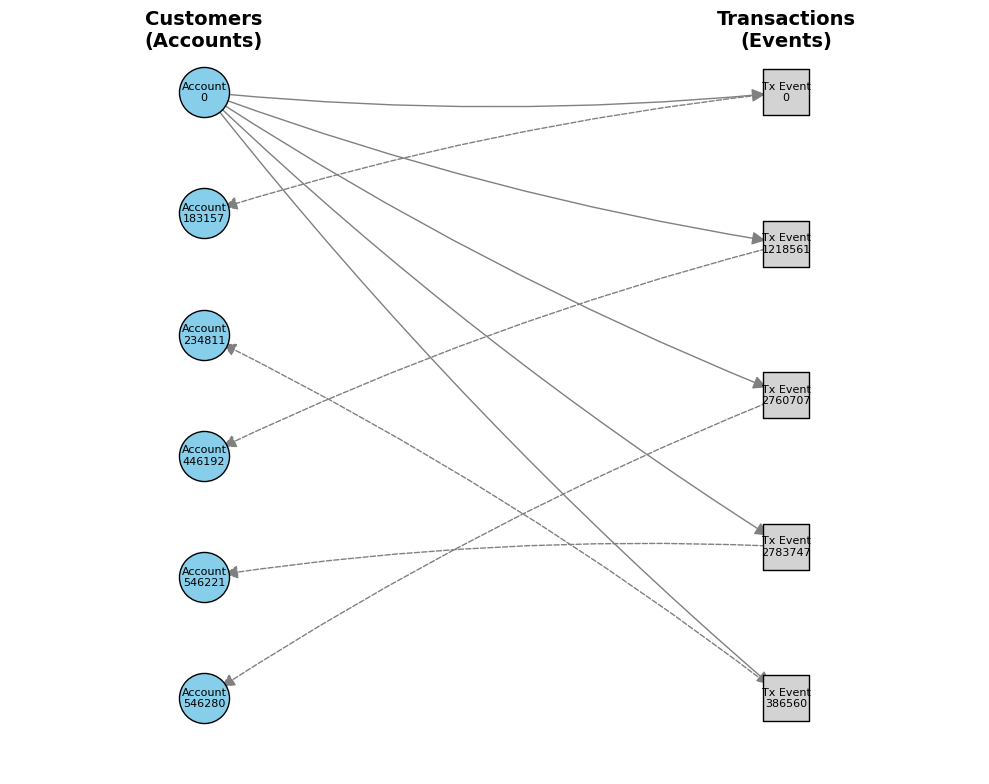

In [135]:
# --- EXECUTE ---
full_df = pd.concat([train_df, test_df], ignore_index=True)
visualize_bipartite_numbered(global_data, full_df, target_tx_count=5)

# Graph Statistics

In [147]:
def calculate_graph_statistics_detailed(global_data, full_df):
    print("--- 📊 GLOBAL LAUNDROGRAPH STATISTICS (DETAILED) ---")
    
    # ---------------------------------------------------------
    # 1. NODE COUNTS
    # ---------------------------------------------------------
    num_cust = global_data['customer'].num_nodes
    num_tx = global_data['transaction'].num_nodes
    print(f"\n1. NODE COUNTS:")
    print(f"   • Total Customers:    {num_cust:,}")
    print(f"   • Total Transactions: {num_tx:,}")
    print(f"   • Graph Ratio:        1 Customer ≈ {num_tx/num_cust:.2f} Transactions")

    # ---------------------------------------------------------
    # 2. EDGE SPLITS (The Breakdown You Requested)
    # ---------------------------------------------------------
    n_mp = len(global_data.mp_mask_ids)
    n_sup = len(global_data.sup_mask_ids)
    n_val = len(global_data.val_mask_ids)
    n_test = len(global_data.test_mask_ids)
    
    total_edges = n_mp + n_sup + n_val + n_test
    
    print(f"\n2. EDGE SPLITS (Detailed Breakdown):")
    print(f"   • Message Passing (MP): {n_mp:,} ({n_mp/total_edges*100:.1f}%)")
    print(f"     (Used strictly for graph connectivity/structure)")
    print(f"   • Supervision (Train):  {n_sup:,} ({n_sup/total_edges*100:.1f}%)")
    print(f"     (Used to calculate loss and update gradients)")
    print(f"   • Validation (Val):     {n_val:,} ({n_val/total_edges*100:.1f}%)")
    print(f"     (Used for hyperparameter tuning & early stopping)")
    print(f"   • Test Set:             {n_test:,} ({n_test/total_edges*100:.1f}%)")
    print(f"     (Held-out for final evaluation)")
    print(f"   -------------------------------------------------")
    print(f"   • TOTAL EDGES:          {total_edges:,}")

    # ---------------------------------------------------------
    # 3. TEST SET IMBALANCE
    # ---------------------------------------------------------
    # Retrieve labels using the Test Indices
    test_indices = global_data.test_mask_ids.cpu().numpy()
    y_test = full_df.iloc[test_indices]['Is_laundering'].values
    
    n_laundering = np.sum(y_test == 1)
    n_normal = np.sum(y_test == 0)
    
    print(f"\n3. TEST SET IMBALANCE:")
    print(f"   • Normal (0):         {n_normal:,}")
    print(f"   • Laundering (1):     {n_laundering:,}")
    print(f"   • Imbalance Ratio:    {n_laundering / (n_laundering + n_normal) * 100:.3f}%")

    # ---------------------------------------------------------
    # 4. COLD START ANALYSIS
    # ---------------------------------------------------------
    train_mask_all = torch.cat([global_data.mp_mask_ids, global_data.sup_mask_ids, global_data.val_mask_ids])
    train_indices = train_mask_all.cpu().numpy()
    
    train_senders = full_df.iloc[train_indices]['Sender_account'].unique()
    test_senders = full_df.iloc[test_indices]['Sender_account'].unique()
    
    train_set = set(train_senders)
    test_set = set(test_senders)
    
    seen_customers = test_set.intersection(train_set)
    new_customers = test_set.difference(train_set)
    
    print(f"\n4. COLD START CHALLENGE (Test Set Composition):")
    print(f"   • Unique Customers in Test: {len(test_set):,}")
    print(f"   • Old (Seen) Customers:     {len(seen_customers):,} ({len(seen_customers)/len(test_set)*100:.1f}%)")
    print(f"   • New (Cold) Customers:     {len(new_customers):,} ({len(new_customers)/len(test_set)*100:.1f}%)")
    
    # ---------------------------------------------------------
    # 5. CONNECTIVITY STATS
    # ---------------------------------------------------------
    sender_counts = full_df['Sender_account'].value_counts()
    
    print(f"\n5. CONNECTIVITY STATS:")
    print(f"   • Max Transactions by one user: {sender_counts.max()}")
    print(f"   • Avg Transactions per user:    {sender_counts.mean():.2f}")
    print(f"   • Median Transactions per user: {sender_counts.median():.2f}")

In [148]:
# --- EXECUTE ---
if 'full_df' not in locals():
    full_df = pd.concat([train_df, test_df], ignore_index=True)

calculate_graph_statistics_detailed(global_data, full_df)

--- 📊 GLOBAL LAUNDROGRAPH STATISTICS (DETAILED) ---

1. NODE COUNTS:
   • Total Customers:    646,548
   • Total Transactions: 5,185,110
   • Graph Ratio:        1 Customer ≈ 8.02 Transactions

2. EDGE SPLITS (Detailed Breakdown):
   • Message Passing (MP): 2,264,264 (43.7%)
     (Used strictly for graph connectivity/structure)
   • Supervision (Train):  1,358,558 (26.2%)
     (Used to calculate loss and update gradients)
   • Validation (Val):     905,706 (17.5%)
     (Used for hyperparameter tuning & early stopping)
   • Test Set:             656,582 (12.7%)
     (Held-out for final evaluation)
   -------------------------------------------------
   • TOTAL EDGES:          5,185,110

3. TEST SET IMBALANCE:
   • Normal (0):         655,752
   • Laundering (1):     830
   • Imbalance Ratio:    0.126%

4. COLD START CHALLENGE (Test Set Composition):
   • Unique Customers in Test: 68,541
   • Old (Seen) Customers:     52,761 (77.0%)
   • New (Cold) Customers:     15,780 (23.0%)

5. CONNE